### KNN Algorithm 

In [32]:
import os
import pandas as pd

dataset_path = "animal"
categories = os.listdir("animal")
print(categories)

['raw-img', 'translate.py']


In [33]:
categories = os.listdir("animal/raw-img")
print(categories)

['cat', 'cow', 'Dog']


In [34]:
data = []

for category in os.listdir("animal/raw-img"):
    category_path = os.path.join("animal/raw-img",category)

    if os.path.isdir(category_path):
        count = len(category_path)
        data.append([category, count])

df = pd.DataFrame(data, columns = ["Category", "Image_count"])
print(df)

  Category  Image_count
0      cat           18
1      cow           18
2      Dog           18


In [44]:
import cv2
import numpy as np
print(cv2.__version__)

4.13.0


In [45]:
X = []  # To store flattened image pixel data
y = []  # To store corresponding labels (e.g., 'butterfly', 'cat')

base_path = "animal/raw-img"
IMG_SIZE = 64  # Resize all images to 64x64

for category in os.listdir(base_path):
    category_path = os.path.join(base_path, category)
    if os.path.isdir(category_path):
        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            
            # Read image in grayscale (easier) or color (change to cv2.IMREAD_COLOR)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is not None:
                # Resize to make all images identical dimensions
                resized_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                
                # Flatten the 2D image array into a 1D row of features
                flattened = resized_img.flatten()
                
                X.append(flattened)
                y.append(category)

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Learn and apply scaling
X_test_scaled = scaler.transform(X_test)       # Apply same scaling rules

In [48]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize KNN (starting with k=5 neighbors is standard)
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred = knn.predict(X_test_scaled)

# Check the results!
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Report:\n", classification_report(y_test, y_pred))

Accuracy: 58.10%

Detailed Report:
               precision    recall  f1-score   support

         Dog       0.62      0.82      0.70       973
         cat       0.35      0.25      0.29       334
         cow       0.63      0.26      0.37       373

    accuracy                           0.58      1680
   macro avg       0.53      0.44      0.45      1680
weighted avg       0.57      0.58      0.55      1680



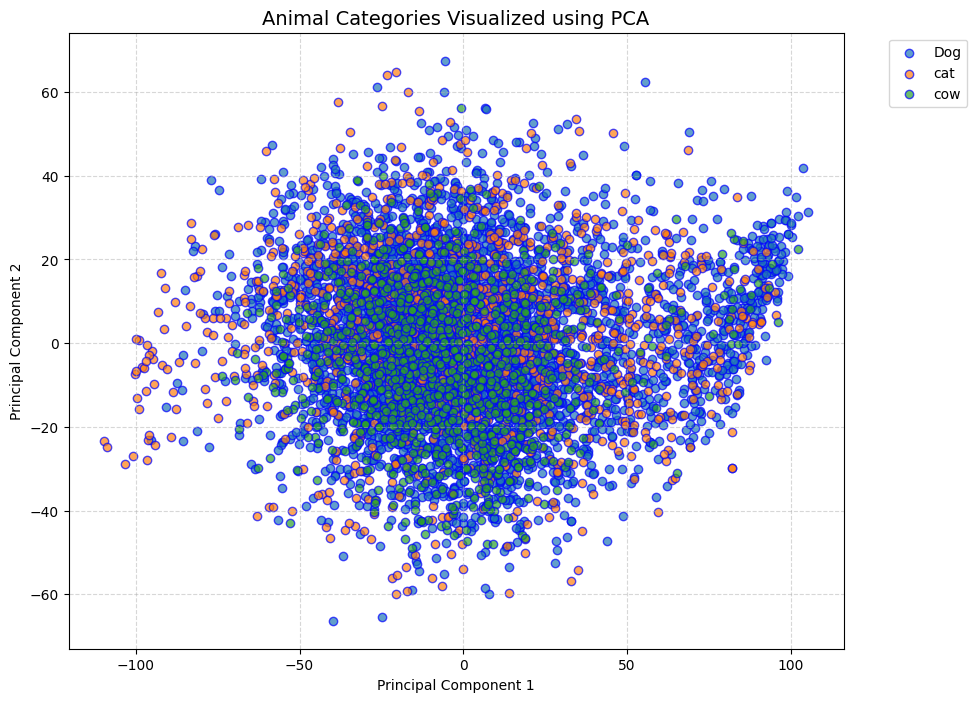

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt 

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

df_plot = pd.DataFrame(X_pca, columns=['Component 1', 'Component 2'])
df_plot['Label'] = y_train

plt.figure(figsize=(10, 8))
categories = df_plot['Label'].unique()

for category in categories:
    subset = df_plot[df_plot['Label'] == category]
    plt.scatter(subset['Component 1'], subset['Component 2'], label=category, alpha=0.7, edgecolors='b')

plt.title('Animal Categories Visualized using PCA', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()